In [3]:
# Threat Prediction using Random Forest
# This notebook trains a Random Forest classifier for detection of different types of attacks

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                            accuracy_score, precision_recall_fscore_support,
                            roc_curve, auc, roc_auc_score)
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')


In [4]:
# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [5]:
# Load data
print("Loading data...")
data_df = pd.read_json(r'C:\Users\mps\Desktop\ML-Final\MLproj\waf\Preprocessing\complete_clean.json', orient='records')
print(f"\nDataset shape: {data_df.shape}")
print(f"\nFirst few rows:")
print(data_df.head())

# Display class distribution
print("\n=== Class Distribution ===")
counts = data_df['type'].value_counts()
print(counts)

Loading data...

Dataset shape: (90253, 2)

First few rows:
                                             pattern   type
0  /l_t@/_feu1wvhtpass2/1nieqnnrvnzktuasain/tg1ar...  valid
1  settotzeertnl='pn &8nafitm=74lukuc5t0j&4ttne=a...  valid
2                  /fonrnt/7n.d-4brssxb@tu/qghew.cfm  valid
3  dfdi7ftp=37redocumentiln&l4setbemmo=oe_rdzq&rt...  valid
4  /2m6vlb1r37jspc/cwvv/mbar/oqrd0/msc/etceebwgi/...  valid

=== Class Distribution ===
type
valid             60623
sqli              13153
xss                9730
cmdi               3461
path-traversal     3286
Name: count, dtype: int64


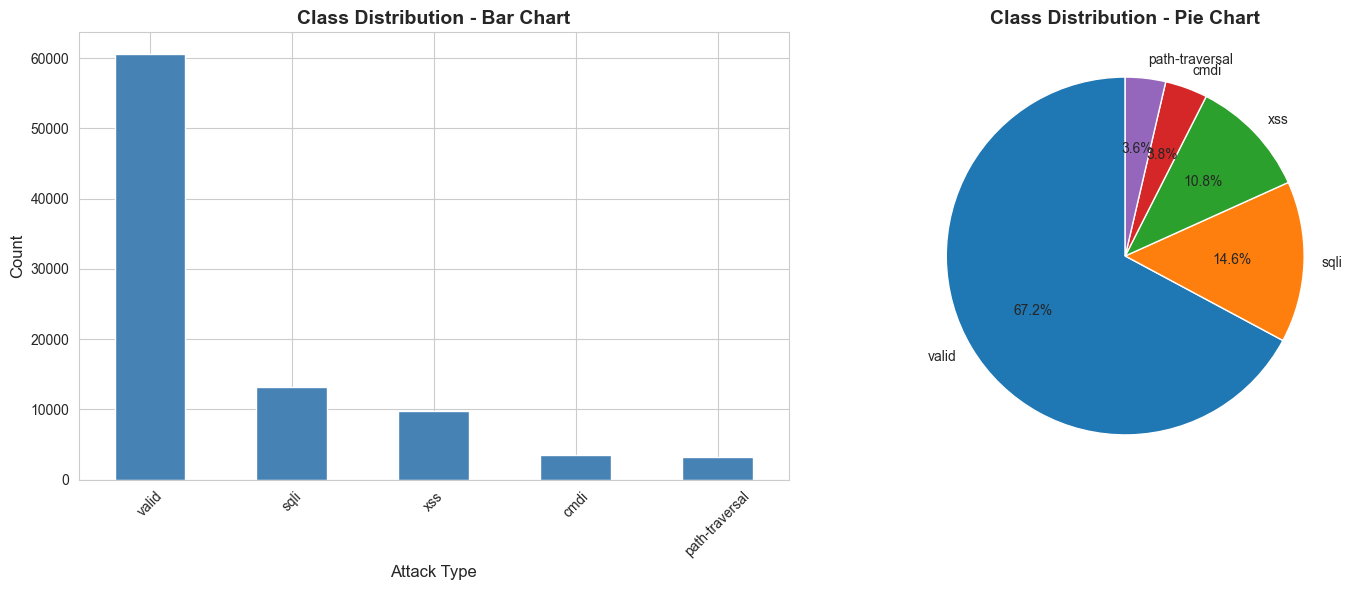

In [6]:
# Visualize class distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Bar plot
counts.plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Class Distribution - Bar Chart', fontsize=14, fontweight='bold')
ax1.set_xlabel('Attack Type', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# Pie chart
counts.plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=90)
ax2.set_ylabel('')
ax2.set_title('Class Distribution - Pie Chart', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [7]:
# Load existing dataset splits
print("\n=== Loading Pre-split Data ===")
dataset = np.load('dataset.npz', allow_pickle=True)
trainX = dataset['trainX']
testX = dataset['testX']
trainY = dataset['trainY']
testY = dataset['testY']

# Convert to Python lists to reduce memory usage during cross-validation
trainX = trainX.tolist()
testX = testX.tolist()
trainY = trainY.tolist()
testY = testY.tolist()

print(f"Training samples: {len(trainX)}")
print(f"Testing samples: {len(testX)}")
print(f"Total samples: {len(trainX) + len(testX)}")
print(f"\nUsing the same train-test split as the original SVM model for fair comparison.")
print("Note: Converted to lists to optimize memory usage during training.")



=== Loading Pre-split Data ===
Training samples: 67689
Testing samples: 22564
Total samples: 90253

Using the same train-test split as the original SVM model for fair comparison.
Note: Converted to lists to optimize memory usage during training.


In [8]:
# Create pipeline and perform grid search
print("\n=== Training Random Forest Model ===")
print("This may take a while...")

pipe = make_pipeline(
    TfidfVectorizer(input='content', lowercase=True, analyzer='char', max_features=1024),
    RandomForestClassifier(random_state=42)
)

# Optimized parameter grid to reduce memory usage and training time
param_grid = {
    'tfidfvectorizer__ngram_range': [(1, 2)],  # Best from SVM
    'randomforestclassifier__n_estimators': [100, 200],
    'randomforestclassifier__max_depth': [20, 30],
    'randomforestclassifier__min_samples_split': [2, 5]
}

# Use n_jobs=2 for limited parallelism to prevent memory issues
grid = GridSearchCV(pipe, param_grid, cv=3, verbose=2, n_jobs=2)
grid.fit(trainX, trainY)

print(f"\n=== Best Parameters ===")
print(grid.best_params_)


=== Training Random Forest Model ===
This may take a while...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

=== Best Parameters ===
{'randomforestclassifier__max_depth': 30, 'randomforestclassifier__min_samples_split': 2, 'randomforestclassifier__n_estimators': 200, 'tfidfvectorizer__ngram_range': (1, 2)}



=== Model Performance ===
Test Accuracy: 0.9890

=== Classification Report ===
                precision    recall  f1-score   support

          cmdi       0.99      0.91      0.95       865
path-traversal       1.00      0.90      0.95       822
          sqli       1.00      0.98      0.99      3288
         valid       0.99      1.00      0.99     15156
           xss       1.00      0.99      0.99      2433

      accuracy                           0.99     22564
     macro avg       0.99      0.96      0.97     22564
  weighted avg       0.99      0.99      0.99     22564


=== Confusion Matrix ===
[[  784     2     6    73     0]
 [    0   743     0    79     0]
 [    8     0  3232    48     0]
 [    0     0     5 15150     1]
 [    0     0     1    25  2407]]


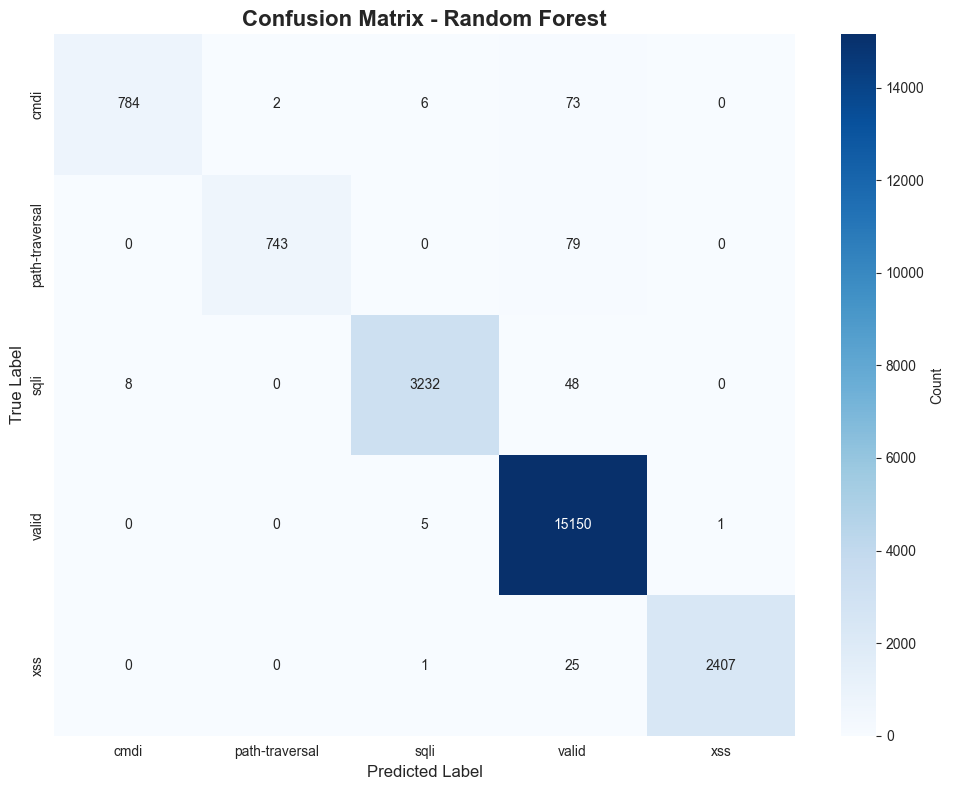

In [9]:
# Evaluate on test set
print(f"\n=== Model Performance ===")
test_score = grid.score(testX, testY)
print(f"Test Accuracy: {test_score:.4f}")

# Get predictions
preds = grid.predict(testX)
proba = grid.predict_proba(testX)

# Detailed classification report
print(f"\n=== Classification Report ===")
print(classification_report(testY, preds))

# Confusion Matrix
print("\n=== Confusion Matrix ===")
cm = confusion_matrix(testY, preds)
print(cm)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
classes = sorted(data_df['type'].unique())
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Random Forest', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
# Save the model
print("\n=== Saving Model ===")
import joblib
joblib.dump(grid, 'predictor_rf.joblib')
print("Model saved as 'predictor_rf.joblib'")

print("\n=== Training Complete ===")


=== Saving Model ===
Model saved as 'predictor_rf.joblib'

=== Training Complete ===
